In [ ]:
import json
import os
import random
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage.io as sio
from matplotlib.patches import Patch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
os.environ["OPENCV_LOG_LEVEL"] = "SILENT"
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "0"

In [ ]:
# =========================================================
# 1. path settings
# =========================================================
DATA_ROOT = Path("hw3-data-release")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
TEST_JSON = DATA_ROOT / "test_image_name_to_ids.json"

CLASS_NAMES = ["class1", "class2", "class3", "class4"]

OUTPUT_ROOT = Path("eda_outputs")
OUTPUT_ROOT.mkdir(exist_ok=True)

In [ ]:
# =========================================================
# 2. Read image and mask
# =========================================================


def read_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError(f"Cannot read image file: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image


def read_mask(path):
    mask = sio.imread(str(path))
    return np.array(mask)

In [ ]:
# =========================================================
# 3. Find instances in the mask
# =========================================================


def get_instances_from_mask(mask):
    instance_ids = np.unique(mask)
    instance_ids = instance_ids[instance_ids != 0]
    return instance_ids

In [ ]:
# =========================================================
# 4. analyze train images
# =========================================================


def analyze_train():
    records = []
    bbox_records = []

    image_folders = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])

    for folder in tqdm(image_folders, desc="Analyzing train images"):
        image_path = folder / "image.tif"

        if not image_path.exists():
            print(f"[Warning] Missing image.tif: {folder}")
            continue

        try:
            image = read_image(image_path)
        except Exception as e:
            print(f"[Bad image] Cannot read: {image_path}")
            print(e)
            continue

        h, w = image.shape[:2]
        total_instances = 0

        for class_idx, class_name in enumerate(CLASS_NAMES, start=1):
            mask_path = folder / f"{class_name}.tif"

            if not mask_path.exists():
                continue

            try:
                mask = read_mask(mask_path)
            except Exception as e:
                print(f"[Bad mask] Cannot read: {mask_path}")
                print(e)
                continue

            if mask.shape[:2] != (h, w):
                print(f"[Warning] Size mismatch: {mask_path}")
                print("image:", image.shape, "mask:", mask.shape)

            instance_ids = get_instances_from_mask(mask)
            total_instances += len(instance_ids)

            for inst_id in instance_ids:
                binary = mask == inst_id
                ys, xs = np.where(binary)

                if len(xs) == 0 or len(ys) == 0:
                    continue

                x_min, x_max = xs.min(), xs.max()
                y_min, y_max = ys.min(), ys.max()

                bbox_w = x_max - x_min + 1
                bbox_h = y_max - y_min + 1
                mask_area = binary.sum()

                bbox_records.append(
                    {
                        "image_name": folder.name,
                        "class_name": class_name,
                        "category_id": class_idx,
                        "instance_id": int(inst_id),
                        "bbox_w": bbox_w,
                        "bbox_h": bbox_h,
                        "bbox_area": bbox_w * bbox_h,
                        "mask_area": mask_area,
                    }
                )

        records.append(
            {
                "image_name": folder.name,
                "height": h,
                "width": w,
                "total_instances": total_instances,
            }
        )

    image_df = pd.DataFrame(records)
    bbox_df = pd.DataFrame(bbox_records)

    return image_df, bbox_df

In [ ]:
# =========================================================
# 5. read test json
# =========================================================


def analyze_test_json():
    with open(TEST_JSON, "r", encoding="utf-8") as f:
        test_info = json.load(f)

    test_df = pd.DataFrame(test_info)
    return test_df

In [ ]:
# =========================================================
# 6. print summary
# =========================================================


def print_summary(image_df, bbox_df, test_df):
    print("=" * 60)
    print("Train image summary")
    print("=" * 60)
    print("Num train images:", len(image_df))
    print(image_df[["height", "width", "total_instances"]].describe())

    print("\n" + "=" * 60)
    print("Test image summary")
    print("=" * 60)
    print("Num test images:", len(test_df))
    print(test_df[["height", "width"]].describe())

    print("\n" + "=" * 60)
    print("Class distribution")
    print("=" * 60)
    print(bbox_df["class_name"].value_counts().sort_index())

    print("\n" + "=" * 60)
    print("BBox / Mask area summary")
    print("=" * 60)
    print(bbox_df[["bbox_w", "bbox_h", "bbox_area", "mask_area"]].describe())

In [ ]:
# =========================================================
# 7. draw plots functions
# =========================================================


def plot_hist(series, title, xlabel, save_path):
    plt.figure(figsize=(7, 5))
    plt.hist(series, bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()


def make_plots(image_df, bbox_df):
    os.makedirs(f"{OUTPUT_ROOT}", exist_ok=True)

    plot_hist(
        image_df["height"],
        "Train Image Height Distribution",
        "Height",
        f"{OUTPUT_ROOT}/train_height_distribution.png",
    )

    plot_hist(
        image_df["width"],
        "Train Image Width Distribution",
        "Width",
        f"{OUTPUT_ROOT}/train_width_distribution.png",
    )

    plot_hist(
        image_df["total_instances"],
        "Instances Per Train Image",
        "Number of Instances",
        f"{OUTPUT_ROOT}/instances_per_image.png",
    )

    plot_hist(
        bbox_df["bbox_area"],
        "BBox Area Distribution",
        "BBox Area",
        f"{OUTPUT_ROOT}/bbox_area_distribution.png",
    )

    plt.figure(figsize=(6, 5))
    bbox_df["class_name"].value_counts().sort_index().plot(kind="bar")
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Instances")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_ROOT}/class_distribution.png")
    plt.show()
    plt.close()

In [ ]:
# =========================================================
# 8. visualize overlay
# =========================================================


def get_color_map():
    return {
        "class1": np.array([255, 0, 0], dtype=np.uint8),  # red
        "class2": np.array([0, 255, 0], dtype=np.uint8),  # green
        "class3": np.array([255, 165, 0], dtype=np.uint8),  # orange
        "class4": np.array([255, 255, 0], dtype=np.uint8),  # yellow
    }


def has_class_instance(folder, class_name):
    mask_path = folder / f"{class_name}.tif"

    if not mask_path.exists():
        return False

    try:
        mask = read_mask(mask_path)
    except Exception:
        return False

    instance_ids = get_instances_from_mask(mask)
    return len(instance_ids) > 0


def find_random_folder_with_class(image_folders, class_name):
    candidates = []

    for folder in tqdm(
        image_folders,
        desc=f"Finding image with {class_name}",
        leave=False,
    ):
        if has_class_instance(folder, class_name):
            candidates.append(folder)

    if len(candidates) == 0:
        print(f"[Warning] No image found with {class_name}")
        return None

    return random.choice(candidates)


def show_one_overlay(folder, save_dir="eda_outputs/overlay"):
    os.makedirs(save_dir, exist_ok=True)

    colors = get_color_map()

    image = read_image(folder / "image.tif")
    image_rgb = image.astype(np.float32)
    overlay = image_rgb.copy()

    existing_classes = []

    for class_name in CLASS_NAMES:
        mask_path = folder / f"{class_name}.tif"

        if not mask_path.exists():
            continue

        try:
            mask = read_mask(mask_path)
        except Exception:
            continue

        binary = mask > 0

        if binary.sum() == 0:
            continue

        existing_classes.append(class_name)

        color = colors[class_name].astype(np.float32)
        overlay[binary] = 0.3 * overlay[binary] + 0.7 * color

    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    legend_items = [
        Patch(facecolor=colors[class_name] / 255, label=class_name)
        for class_name in CLASS_NAMES
    ]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image.astype(np.uint8))
    plt.title(f"Original\n{folder.name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Overlay: {', '.join(existing_classes)}")
    plt.axis("off")

    plt.legend(
        handles=legend_items,
        loc="lower center",
        bbox_to_anchor=(-0.1, -0.18),
        ncol=4,
    )

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{folder.name}.png")
    plt.show()
    plt.close()


def visualize_overlay_class_examples():
    image_folders = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])

    selected_folders = []

    for class_name in CLASS_NAMES:
        folder = find_random_folder_with_class(image_folders, class_name)
        if folder is not None:
            selected_folders.append(folder)

    random_folder = random.choice(image_folders)
    selected_folders.append(random_folder)

    for folder in tqdm(selected_folders, desc="Showing selected overlays"):
        show_one_overlay(folder)

In [ ]:
# =========================================================
# 9. main function
# =========================================================


def main():
    image_df, bbox_df = analyze_train()
    test_df = analyze_test_json()

    print_summary(image_df, bbox_df, test_df)

    image_df.to_csv(f"{OUTPUT_ROOT}/train_images.csv", index=False)
    bbox_df.to_csv(f"{OUTPUT_ROOT}/instances.csv", index=False)
    test_df.to_csv(f"{OUTPUT_ROOT}/test_images.csv", index=False)

    make_plots(image_df, bbox_df)
    visualize_overlay_class_examples()

    print("\nDone.")
    print("CSV files and figures are saved in: eda_outputs/")

Analyzing train images:   0%|          | 0/209 [00:00<?, ?it/s]

Train image summary
Num train images: 209
            height        width  total_instances
count   209.000000   209.000000       209.000000
mean    563.947368   628.320574       150.272727
std     371.355640   409.953512       175.274887
min      81.000000    74.000000         2.000000
25%     273.000000   311.000000        10.000000
50%     500.000000   523.000000        58.000000
75%     788.000000   859.000000       270.000000
max    1956.000000  2162.000000       772.000000

Test image summary
Num test images: 101
            height        width
count   101.000000   101.000000
mean    547.851485   548.693069
std     491.289902   413.162722
min      33.000000    35.000000
25%     206.000000   264.000000
50%     374.000000   464.000000
75%     655.000000   726.000000
max    2500.000000  1987.000000

Class distribution
class_name
class1    14537
class2    15653
class3      630
class4      587
Name: count, dtype: int64

BBox / Mask area summary
             bbox_w        bbox_h     bbo

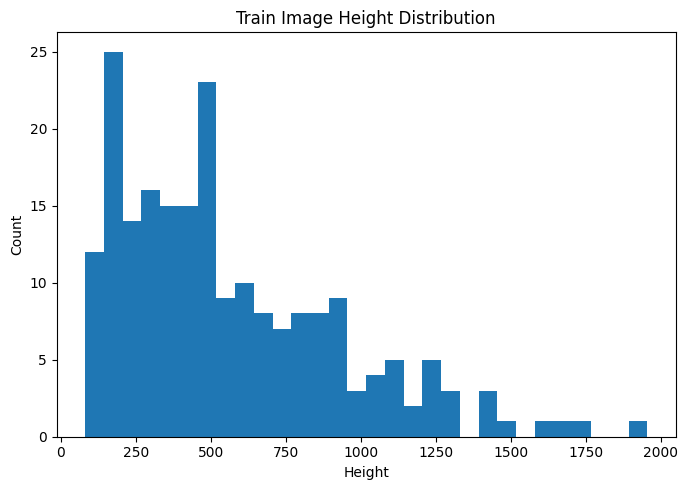

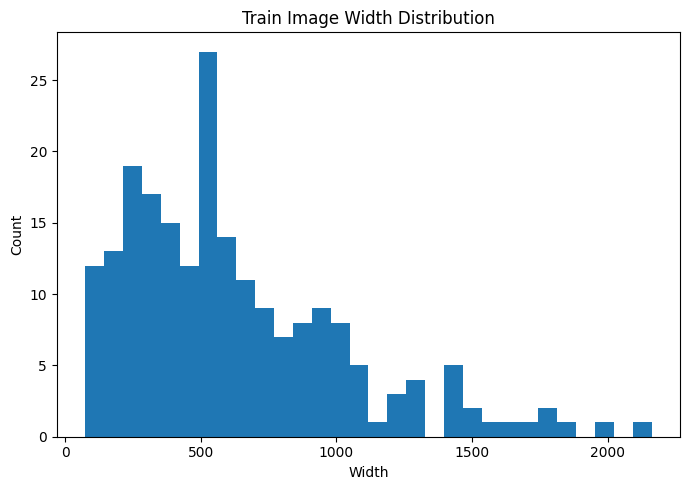

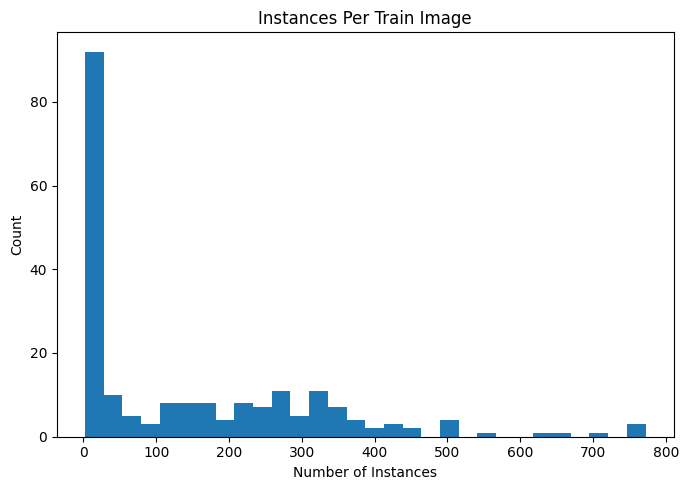

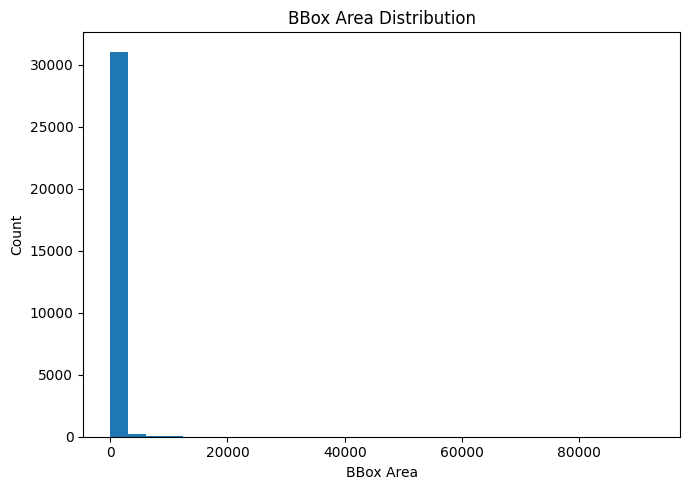

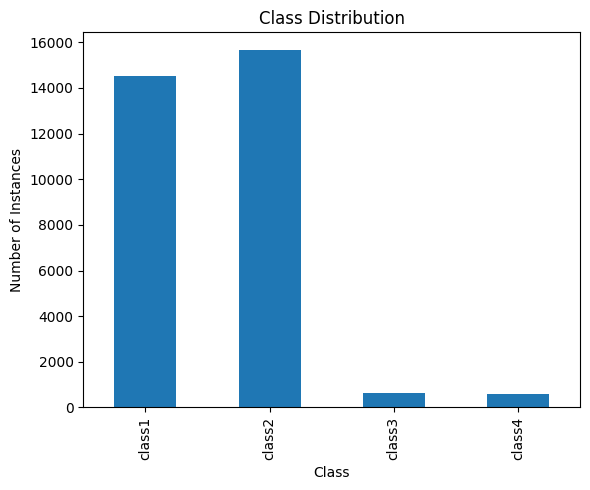

Finding image with class1:   0%|          | 0/209 [00:00<?, ?it/s]

Finding image with class2:   0%|          | 0/209 [00:00<?, ?it/s]

Finding image with class3:   0%|          | 0/209 [00:00<?, ?it/s]

Finding image with class4:   0%|          | 0/209 [00:00<?, ?it/s]

Showing selected overlays:   0%|          | 0/5 [00:00<?, ?it/s]

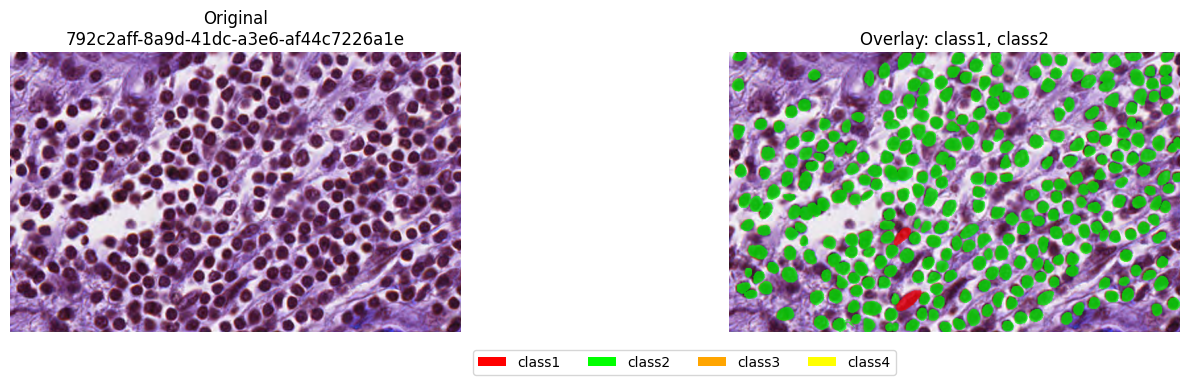

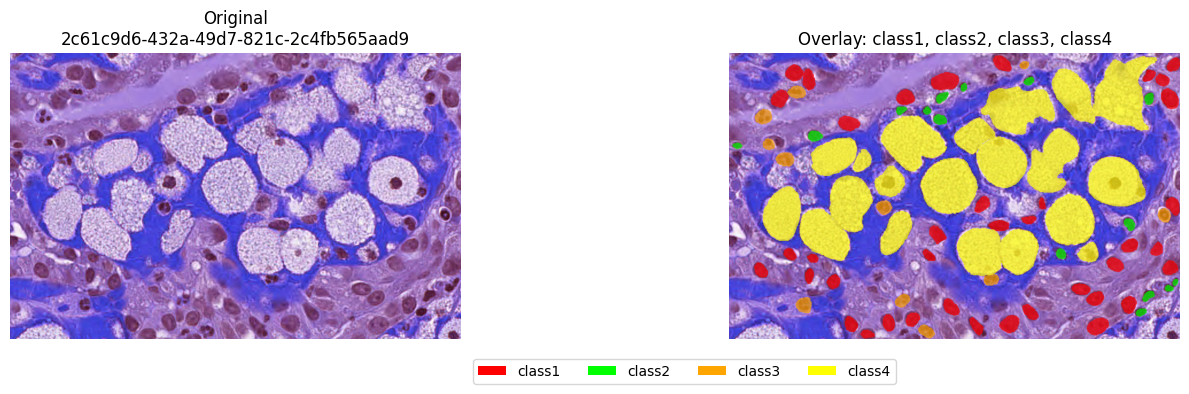

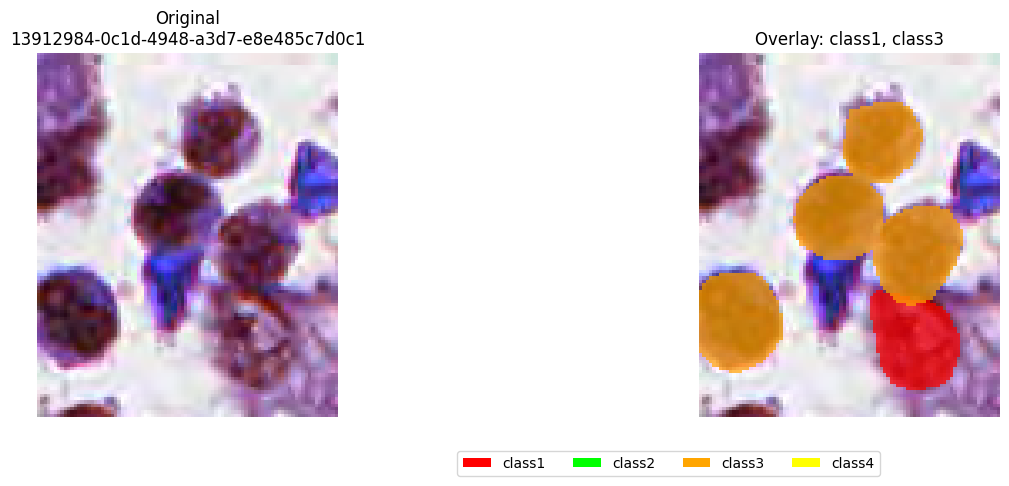

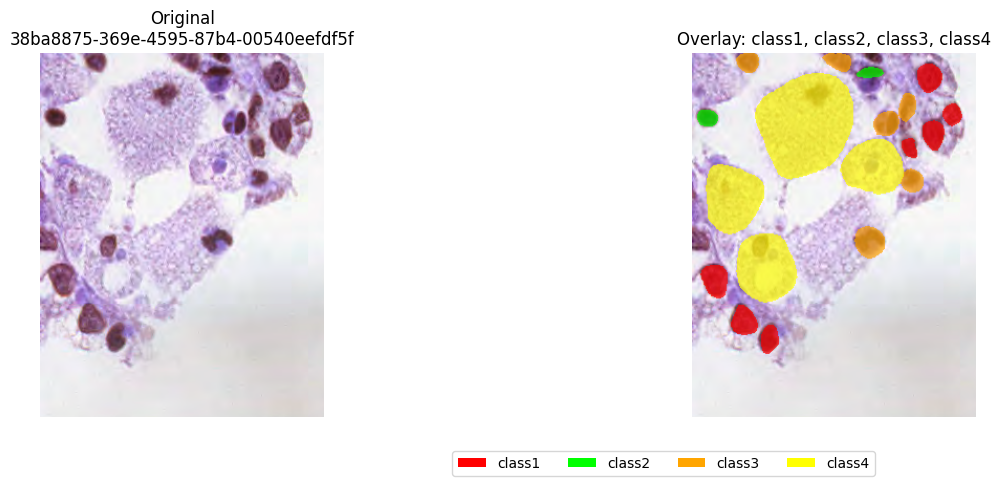

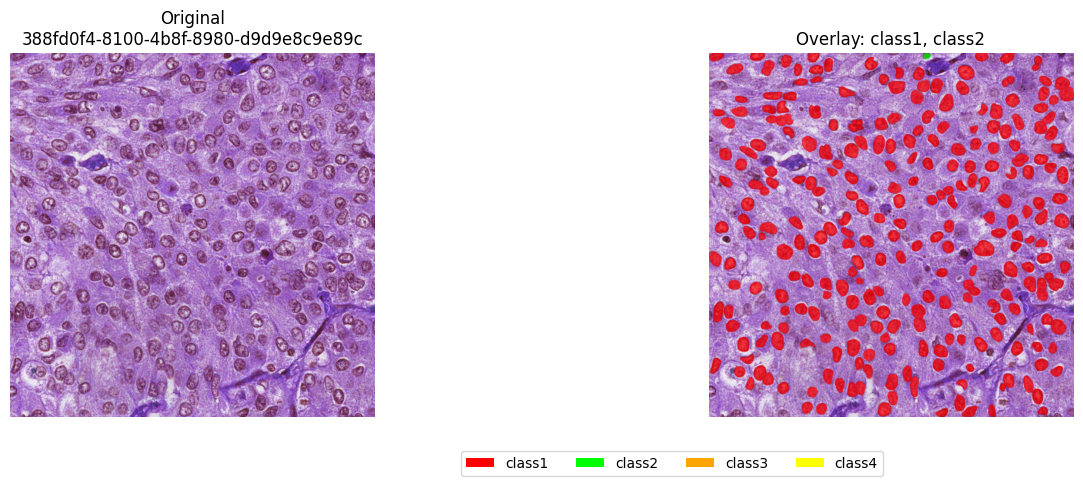


Done.
CSV files and figures are saved in: eda_outputs/


In [12]:
if __name__ == "__main__":
    main()